### Processamento de linguagem natural com Python

#### Importação das bibliotecas

In [3]:
!pip install spacy

   ---------------------------------------- 0.0/14.2 MB ? eta -:--:--
    --------------------------------------- 0.3/14.2 MB ? eta -:--:--
   -- ------------------------------------- 0.8/14.2 MB 2.1 MB/s eta 0:00:07
   ---- ----------------------------------- 1.6/14.2 MB 3.0 MB/s eta 0:00:05
   -------- ------------------------------- 2.9/14.2 MB 4.0 MB/s eta 0:00:03
   --------- ------------------------------ 3.4/14.2 MB 3.6 MB/s eta 0:00:04
   ----------- ---------------------------- 3.9/14.2 MB 3.6 MB/s eta 0:00:03
   -------------- ------------------------- 5.0/14.2 MB 3.7 MB/s eta 0:00:03
   ---------------- ----------------------- 6.0/14.2 MB 3.9 MB/s eta 0:00:03
   ------------------- -------------------- 6.8/14.2 MB 3.9 MB/s eta 0:00:02
   ------------------------ --------------- 8.7/14.2 MB 4.4 MB/s eta 0:00:02
   ------------------------------ --------- 10.7/14.2 MB 4.9 MB/s eta 0:00:01
   ------------------------------------- -- 13.4/14.2 MB 5.6 MB/s eta 0:00:01
   --------

In [4]:
import bs4 as bs
import urllib.request
import nltk
import spacy

In [5]:
!pip install spacy download pt

ERROR: Could not find a version that satisfies the requirement pt (from versions: none)
ERROR: No matching distribution found for pt


### Marcação POS
- POS (part-of-speech) atribui para as palavras partes da fala, como substantivos, adjetivos, verbos
- Importante para a detecção de entidades no texto, pois primeiro é necessário saber o que o texto contém
- Lista de tokens: https://spacy.io/api/annotation#pos-tagging
- Português: https://www.sketchengine.eu/portuguese-freeling-part-of-speech-tagset/

In [10]:
!python -m spacy download pt_core_news_sm

     ---------------------------------------- 0.0/13.0 MB ? eta -:--:--
     ---------- ----------------------------- 3.4/13.0 MB 27.8 MB/s eta 0:00:01
     --------------------------------------- 13.0/13.0 MB 41.2 MB/s eta 0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('pt_core_news_sm')


In [12]:
pln = spacy.load("pt_core_news_sm")
pln

In [13]:
documento = pln("O Brasil é um país do continente americano. A capital do Brasil é Brasília.")
documento

O Brasil é um país do continente americano. A capital do Brasil é Brasília.

In [14]:
type(documento)

spacy.tokens.doc.Doc

In [17]:
for token in documento:
    print(token.text, token.pos_, token.dep_)

O DET det
Brasil PROPN nsubj
é AUX cop
um DET det
país NOUN ROOT
do ADP case
continente NOUN nmod
americano ADJ amod
. PUNCT punct
A DET det
capital NOUN nsubj
do ADP case
Brasil PROPN nmod
é AUX cop
Brasília PROPN ROOT
. PUNCT punct


### Lematização e stemização

In [18]:
for token in documento:
    print(token.text, token.lemma_)

O o
Brasil Brasil
é ser
um um
país país
do de o
continente continente
americano americano
. .
A o
capital capital
do de o
Brasil Brasil
é ser
Brasília Brasília
. .


In [19]:
doc = pln("encontrei encontraram encontrarão encontrariam cursando curso cursei.")
[token.lemma_ for token in doc]

['encontrar',
 'encontrar',
 'encontrar',
 'encontrariar',
 'cursar',
 'curso',
 'cursar',
 '.']

In [20]:
import nltk
nltk.download('rslp')

[nltk_data] Downloading package rslp to
[nltk_data]     C:\Users\Olive\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping stemmers\rslp.zip.


True

In [21]:
stremmer = nltk.stem.RSLPStemmer()
stremmer.stem("apender")

'apend'

In [24]:
import spacy
from nltk.stem import RSLPStemmer

pln = spacy.load("pt_core_news_sm")
stemmer = RSLPStemmer()

documento = pln("Estou estudando análise de dados e machine learning")

for token in documento:
    print(token.text, token.lemma_, stemmer.stem(token.text))

Estou estar est
estudando estudar estud
análise análise anális
de de de
dados dado dad
e e e
machine machine machin
learning learning learning


### Carregamento dos textos

In [44]:
import requests

url = "https://pt.wikipedia.org/wiki/Intelig%C3%AAncia_artificial"

headers = {
    "User-Agent": "Mozilla/5.0"
}

response = requests.get(url, headers=headers)

html = response.text

dados = html.encode("utf-8")
print(dados)


b'<!DOCTYPE html>\n<html class="client-nojs vector-feature-language-in-header-enabled vector-feature-language-in-main-menu-disabled vector-feature-language-in-main-page-header-disabled vector-feature-page-tools-pinned-disabled vector-feature-toc-pinned-clientpref-1 vector-feature-main-menu-pinned-disabled vector-feature-limited-width-clientpref-1 vector-feature-limited-width-content-enabled vector-feature-custom-font-size-clientpref-1 vector-feature-appearance-pinned-clientpref-1 skin-theme-clientpref-day vector-sticky-header-enabled vector-toc-available skin-theme-clientpref-thumb-standard" lang="pt" dir="ltr">\n<head>\n<meta charset="UTF-8">\n<title>Intelig\xc3\xaancia artificial \xe2\x80\x93 Wikip\xc3\xa9dia, a enciclop\xc3\xa9dia livre</title>\n<script>(function(){var className="client-js vector-feature-language-in-header-enabled vector-feature-language-in-main-menu-disabled vector-feature-language-in-main-page-header-disabled vector-feature-page-tools-pinned-disabled vector-featur

In [45]:
dados

b'<!DOCTYPE html>\n<html class="client-nojs vector-feature-language-in-header-enabled vector-feature-language-in-main-menu-disabled vector-feature-language-in-main-page-header-disabled vector-feature-page-tools-pinned-disabled vector-feature-toc-pinned-clientpref-1 vector-feature-main-menu-pinned-disabled vector-feature-limited-width-clientpref-1 vector-feature-limited-width-content-enabled vector-feature-custom-font-size-clientpref-1 vector-feature-appearance-pinned-clientpref-1 skin-theme-clientpref-day vector-sticky-header-enabled vector-toc-available skin-theme-clientpref-thumb-standard" lang="pt" dir="ltr">\n<head>\n<meta charset="UTF-8">\n<title>Intelig\xc3\xaancia artificial \xe2\x80\x93 Wikip\xc3\xa9dia, a enciclop\xc3\xa9dia livre</title>\n<script>(function(){var className="client-js vector-feature-language-in-header-enabled vector-feature-language-in-main-menu-disabled vector-feature-language-in-main-page-header-disabled vector-feature-page-tools-pinned-disabled vector-featur

In [46]:
dados_html = bs.BeautifulSoup(dados, "lxml")
dados_html

<!DOCTYPE html>
<html class="client-nojs vector-feature-language-in-header-enabled vector-feature-language-in-main-menu-disabled vector-feature-language-in-main-page-header-disabled vector-feature-page-tools-pinned-disabled vector-feature-toc-pinned-clientpref-1 vector-feature-main-menu-pinned-disabled vector-feature-limited-width-clientpref-1 vector-feature-limited-width-content-enabled vector-feature-custom-font-size-clientpref-1 vector-feature-appearance-pinned-clientpref-1 skin-theme-clientpref-day vector-sticky-header-enabled vector-toc-available skin-theme-clientpref-thumb-standard" dir="ltr" lang="pt">
<head>
<meta charset="utf-8"/>
<title>Inteligência artificial – Wikipédia, a enciclopédia livre</title>
<script>(function(){var className="client-js vector-feature-language-in-header-enabled vector-feature-language-in-main-menu-disabled vector-feature-language-in-main-page-header-disabled vector-feature-page-tools-pinned-disabled vector-feature-toc-pinned-clientpref-1 vector-featu

In [47]:
paragrafos = dados_html.find_all("p")
len(paragrafos)

45

In [48]:
paragrafos[1]

<p id="mwMw"><a class="mw-redirect" href="//pt.wikipedia.org/wiki/Aplicativos_de_inteligência_artificial" id="mwNA" rel="mw:WikiLink" title="Aplicativos de inteligência artificial">Aplicações de IA</a> incluem mecanismos avançados de busca na web (por exemplo, <a href="//pt.wikipedia.org/wiki/Google_Busca" id="mwNQ" rel="mw:WikiLink" title="Google Busca">Google Search</a>); <a href="//pt.wikipedia.org/wiki/Sistema_de_recomendação" id="mwNg" rel="mw:WikiLink" title="Sistema de recomendação">sistemas de recomendação</a> (usados pelo <a href="//pt.wikipedia.org/wiki/YouTube" id="mwNw" rel="mw:WikiLink" title="YouTube">YouTube</a>, <a href="//pt.wikipedia.org/wiki/Amazon" id="mwOA" rel="mw:WikiLink" title="Amazon">Amazon</a> e <a href="//pt.wikipedia.org/wiki/Netflix" id="mwOQ" rel="mw:WikiLink" title="Netflix">Netflix</a>); <a href="//pt.wikipedia.org/wiki/Assistente_virtual_inteligente" id="mwOg" rel="mw:WikiLink" title="Assistente virtual inteligente">assistentes virtuais</a> (por exemp

In [49]:
paragrafos[1].text

'Aplicações de IA incluem mecanismos avançados de busca na web (por exemplo, Google Search); sistemas de recomendação (usados pelo YouTube, Amazon e Netflix); assistentes virtuais (por exemplo, Google Assistant, Siri e Alexa ); veículos autônomos (por exemplo, Waymo); ferramentas generativas e criativas (por exemplo, ChatGPT, DeepSeek e AI art); e jogo e análise sobre-humanos em jogos de estratégia (por exemplo, xadrez e Go). No entanto, muitas aplicações de IA não são percebidas como IA porque já se tornaram comuns o suficiente no cotidiano das pessoas.[7][8] Como por exemplo, o reconhecimento óptico de caracteres (OCR) que extrai o texto de imagens; transforma conteúdo não estruturado em dados estruturados com insights prontos para negócios;[1] tradução de textos em idiomas estrangeiros e tradução de voz.[4]'

In [50]:
conteudo = ''
for p in paragrafos:
    conteudo += p.text

In [51]:
conteudo

'Inteligência Artificial (abreviado IA) genericamente é a inteligência, o raciocínio e o aprendizado exibida por máquinas semelhante ao raciocino humano;[1][2] busca desenvolver máquinas autônomas ou sistemas especialistas capazes de simular o pensamento humano e realizar várias tarefas complexas de forma independente.[3] É o sistema que permite aos computadores executar funções avançadas, como a capacidade de analisar dados em grande escala e fazer previsões/recomendações;[1][4] É um campo de pesquisa em ciência da computação que desenvolve e estuda métodos e softwares que permitem que as máquinas percebam seu ambiente e usem o aprendizado e a inteligência para tomar ações que maximizem suas chances de atingir objetivos definidos.[5] A IA iniciou na década de 1950 com os pesquisadores Alan Turing e Herbert Simon baseado no conceito do filósofo grego Aristóteles. Em 1950, o matemático inglês Allan Turing escreveu sobre ser possível uma máquina pensar, e imitar o comportamento humano in

In [52]:
conteudo = conteudo.lower()
conteudo

'inteligência artificial (abreviado ia) genericamente é a inteligência, o raciocínio e o aprendizado exibida por máquinas semelhante ao raciocino humano;[1][2] busca desenvolver máquinas autônomas ou sistemas especialistas capazes de simular o pensamento humano e realizar várias tarefas complexas de forma independente.[3] é o sistema que permite aos computadores executar funções avançadas, como a capacidade de analisar dados em grande escala e fazer previsões/recomendações;[1][4] é um campo de pesquisa em ciência da computação que desenvolve e estuda métodos e softwares que permitem que as máquinas percebam seu ambiente e usem o aprendizado e a inteligência para tomar ações que maximizem suas chances de atingir objetivos definidos.[5] a ia iniciou na década de 1950 com os pesquisadores alan turing e herbert simon baseado no conceito do filósofo grego aristóteles. em 1950, o matemático inglês allan turing escreveu sobre ser possível uma máquina pensar, e imitar o comportamento humano in

### Buscas em textos com spaCy

In [53]:
pln = spacy.load("pt_core_news_sm")
pln

In [54]:
string = 'turing'
token_pesquisa = pln(string)

In [55]:
pln.vocab

In [56]:
from spacy.matcher import PhraseMatcher
matcher = PhraseMatcher(pln.vocab)
matcher.add("SEARCH", [token_pesquisa])

In [57]:
doc = pln(conteudo)
matches = matcher(doc)
matches

[(8661325627334373315, 126, 127),
 (8661325627334373315, 145, 146),
 (8661325627334373315, 817, 818),
 (8661325627334373315, 826, 827),
 (8661325627334373315, 863, 864),
 (8661325627334373315, 999, 1000),
 (8661325627334373315, 2882, 2883),
 (8661325627334373315, 2892, 2893),
 (8661325627334373315, 3182, 3183)]

In [58]:
doc[2333:2334], doc[2333:2334+5]

(de, de ler as emoções dos outros)

In [59]:
matches[0], matches[0][1], matches[0][2]

((8661325627334373315, 126, 127), 126, 127)

In [60]:
from IPython.core.display import HTML
texto = ''
numero_palavras = 50
doc = pln(conteudo)
matches = matcher(doc)

display(HTML(f'<h1>{string.upper()}</h1>'))
display(HTML(f"""<p><strong>Resultados encontrados:</strong> {len(matches)}</p>"""))
for i in matches:
  inicio = i[1] - numero_palavras
  if inicio < 0:
    inicio = 0
  texto += str(doc[inicio:i[2] + numero_palavras]).replace(string, f"<mark>{string}</mark>")
  texto += "<br /><br />"
display(HTML(f"""... {texto} ... """))

### Extração de entidades nomeadas
- NER (Named-Entity Recognition)
- Encontrar e classificar entidades no texto, dependendo da base de dados que foi utilizada para o treinamento (pessoa, localização, empresa, numéricos)
- Usado em chatbots para saber o assunto falado
- Siglas: https://spacy.io/api/annotation#named-entities

In [61]:
for entidade in doc.ents:
    print(entidade.text, entidade.label_)

alan turing PER
herbert simon PER
aristóteles PER
allan turing PER
google search MISC
youtube MISC
amazon ORG
netflix PER
google assistant MISC
siri PER
waymo PER
go LOC
pessoas.[7][8 MISC
história,[12 ORG
robótica.[14 MISC
aristóteles PER
alexandre PER
allan turing PER
herbert simon PER
john mccarthy PER
turing PER
computing machinery and inteiligence MISC
turing PER
herbert simon PER
allen newell PER
“ PER
turing PER
herbert simon PER
allen newell PER
the simulation of human thought MISC
humano.[19]a PER
allen newell PER
herbert simon PER
marvin minsky PER
mit ORG
lab MISC
conexionismo.[21]o simbolismo ORG
prolog MISC
gpt-3[25 ORG
transformers,[26 MISC
andreas kaplan PER
michael haenlein PER
flexível”.[28 MISC
john mccarthy PER
román LOC
melhor.[31]não LOC
john haugeland PER
autônoma.[36]embora MISC
constante.[37]agêntica LOC
específicos.[37]considerada LOC
siri MISC
movimentos,[36 ORG
humanos.[36]entre LOC
isaac asimov PER
steven spielberg PER
stephen hawking PER
máquinas). MISC
ala

In [62]:
from spacy import displacy
displacy.render(doc, style="ent", jupyter=True)

### Nuvem de palavras e stop words

In [63]:
from spacy.lang.pt.stop_words import STOP_WORDS
print(STOP_WORDS)

{'boa', 'vos', 'menor', 'muito', 'aos', 'pois', 'essas', 'estivemos', 'tais', 'você', 'vem', 'exemplo', 'dezassete', 'onze', 'fomos', 'quinze', 'questão', 'temos', 'todas', 'aquele', 'aquilo', 'terceiro', 'está', 'contra', 'mil', 'foram', 'nuns', 'tentei', 'tendes', 'pela', 'custa', 'nenhuma', 'toda', 'vindo', 'ter', 'deve', 'fim', 'onde', 'iniciar', 'maioria', 'número', 'também', 'quarta', 'vai', 'vinda', 'fazeis', 'ver', 'porquê', 'mas', 'ali', 'perto', 'dá', 'atrás', 'dentro', 'posso', 'tiveram', 'tive', 'é', 'nessa', 'querem', 'já', 'tente', 'forma', 'nossa', 'quero', 'tipo', 'grupo', 'naquele', 'quanto', 'sexto', 'dessa', 'pontos', 'sem', 'através', 'conhecido', 'vossos', 'e', 'quê', 'disso', 'aqueles', 'estás', 'quarto', 'teve', 'geral', 'usar', 'catorze', 'em', 'valor', 'tempo', 'agora', 'quinto', 'vocês', 'ontem', 'próprio', 'portanto', 'tenho', 'menos', 'primeira', 'minha', 'então', 'assim', 'das', 'da', 'à', 'vós', 'estes', 'segunda', 'certeza', 'tua', 'fui', 'qual', 'ainda',

In [64]:
pln.vocab['usa'].is_stop

True

In [65]:
doc = pln(conteudo)
lista_token = []
for token in doc:
    lista_token.append(token.text)

In [66]:
print(lista_token)

['inteligência', 'artificial', '(', 'abreviado', 'ia', ')', 'genericamente', 'é', 'a', 'inteligência', ',', 'o', 'raciocínio', 'e', 'o', 'aprendizado', 'exibida', 'por', 'máquinas', 'semelhante', 'ao', 'raciocino', 'humano;[1][2', ']', 'busca', 'desenvolver', 'máquinas', 'autônomas', 'ou', 'sistemas', 'especialistas', 'capazes', 'de', 'simular', 'o', 'pensamento', 'humano', 'e', 'realizar', 'várias', 'tarefas', 'complexas', 'de', 'forma', 'independente.[3', ']', 'é', 'o', 'sistema', 'que', 'permite', 'aos', 'computadores', 'executar', 'funções', 'avançadas', ',', 'como', 'a', 'capacidade', 'de', 'analisar', 'dados', 'em', 'grande', 'escala', 'e', 'fazer', 'previsões', '/', 'recomendações;[1][4', ']', 'é', 'um', 'campo', 'de', 'pesquisa', 'em', 'ciência', 'da', 'computação', 'que', 'desenvolve', 'e', 'estuda', 'métodos', 'e', 'softwares', 'que', 'permitem', 'que', 'as', 'máquinas', 'percebam', 'seu', 'ambiente', 'e', 'usem', 'o', 'aprendizado', 'e', 'a', 'inteligência', 'para', 'tomar',

In [67]:
len(lista_token)

3940

In [68]:
sem_stop = []
for palavra in lista_token:
    if pln.vocab[palavra].is_stop == False:
        sem_stop.append(palavra)

In [69]:
print(sem_stop)

['inteligência', 'artificial', '(', 'abreviado', 'ia', ')', 'genericamente', 'inteligência', ',', 'raciocínio', 'aprendizado', 'exibida', 'máquinas', 'semelhante', 'raciocino', 'humano;[1][2', ']', 'busca', 'desenvolver', 'máquinas', 'autônomas', 'sistemas', 'especialistas', 'capazes', 'simular', 'pensamento', 'humano', 'realizar', 'várias', 'tarefas', 'complexas', 'independente.[3', ']', 'permite', 'computadores', 'executar', 'funções', 'avançadas', ',', 'capacidade', 'analisar', 'dados', 'escala', 'previsões', '/', 'recomendações;[1][4', ']', 'campo', 'pesquisa', 'ciência', 'computação', 'desenvolve', 'estuda', 'métodos', 'softwares', 'permitem', 'máquinas', 'percebam', 'ambiente', 'usem', 'aprendizado', 'inteligência', 'tomar', 'ações', 'maximizem', 'chances', 'atingir', 'objetivos', 'definidos.[5', ']', 'ia', 'iniciou', 'década', '1950', 'pesquisadores', 'alan', 'turing', 'herbert', 'simon', 'baseado', 'conceito', 'filósofo', 'grego', 'aristóteles', '.', '1950', ',', 'matemático', 

In [70]:
len(sem_stop)

2354

In [74]:
from matplotlib.colors import ListedColormap
color_map = ListedColormap(['orange', 'green', 'red', 'magenta'])

In [78]:
! pip install wordcloud

In [79]:
from wordcloud import WordCloud
cloud = WordCloud(background_color = 'white', max_words = 100, colormap=color_map)

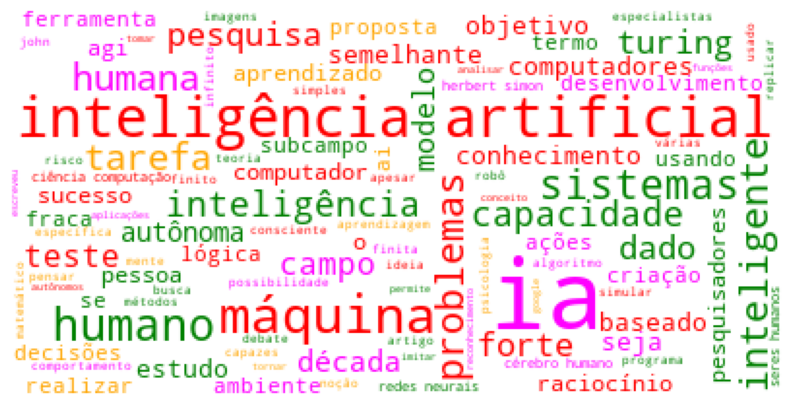

In [85]:
import matplotlib.pyplot as plt
cloud = cloud.generate(' '.join(sem_stop))
plt.figure(figsize=(10,10))
plt.imshow(cloud)
plt.axis('off')
plt.show()